In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abyssmoron/bnm5678/led/Ledger.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_07.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_05.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2026_06.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2026_04.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_04.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_02.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2024_12.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2026_08.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_09.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_08.csv
/kaggle/input/datasets/

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/abyssmoron/bnm5678/led/Ledger.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_07.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_05.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2026_06.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2026_04.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_04.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_02.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2024_12.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2026_08.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_09.csv
/kaggle/input/datasets/abyssmoron/bnm5678/archive (10)/transactions/transaction_2025_08.csv
/kaggle/input/datasets/

In [5]:
path = kagglehub.dataset_download("abyssmoron/bnm5678")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/abyssmoron/bnm5678


In [6]:
df = pd.read_csv(os.path.join(path, "led", "Ledger.csv"), low_memory=False)
df.head()

,SlNo.,ClientID,CreatedAt,MemberID,BillID,LedgerType,Narration,Debit,Credit,Balance,PreviousBalance,ReferenceID
0,13096396.0,P71057,27 Aug 2026 23:59:58,151,270826_47660835,BILL,Trade bill for BTCUSD,123,0.00,10244.65,10367.85,NaN
1,13096395.0,M155101,27 Aug 2026 23:59:55,151,4cad1066-a245-11f1-9131-2a83bccb88bd,WITHDRAW,Ledger entry for WITHDRAW,5000,0.00,4693.52,9693.52,NaN
2,13096394.0,P62149,27 Aug 2026 23:59:52,151,270826_47660834,BILL,Trade bill for BTCUSD,0,353.41,12655.67,12302.26,NaN
3,13096392.0,M129746,27 Aug 2026 23:59:47,151,270826_47660832,BILL,Trade bill for XRPUSD,158,0.00,11380.35,11537.85,NaN
4,13096391.0,M129746,27 Aug 2026 23:59:47,151,270826_47660831,BILL,Trade bill for BTCUSD,62,0.00,11537.85,11600.25,NaN


In [7]:
df.columns

Index(['SlNo.', 'ClientID', 'CreatedAt', 'MemberID', 'BillID', 'LedgerType',
       'Narration', 'Debit', 'Credit', 'Balance', 'PreviousBalance',
       'ReferenceID'],
      dtype='object')

In [8]:
TRADE_TYPES = ["BILL"]

In [9]:
led = df[["ClientID", "CreatedAt", "LedgerType"]]
led = led[led["LedgerType"].isin(TRADE_TYPES)].copy()
led.head()

,ClientID,CreatedAt,LedgerType
0,P71057,27 Aug 2026 23:59:58,BILL
2,P62149,27 Aug 2026 23:59:52,BILL
3,M129746,27 Aug 2026 23:59:47,BILL
4,M129746,27 Aug 2026 23:59:47,BILL
5,S39238,27 Aug 2026 23:59:47,BILL


In [10]:
led["CreatedAt"] = pd.to_datetime(led["CreatedAt"], format="%d %b %Y %H:%M:%S")
led["Month"] = led["CreatedAt"].dt.to_period("M")
led.head()

,ClientID,CreatedAt,LedgerType,Month
0,P71057,2026-08-27 23:59:58,BILL,2026-08
2,P62149,2026-08-27 23:59:52,BILL,2026-08
3,M129746,2026-08-27 23:59:47,BILL,2026-08
4,M129746,2026-08-27 23:59:47,BILL,2026-08
5,S39238,2026-08-27 23:59:47,BILL,2026-08


In [11]:
activity = led[["ClientID", "Month"]].drop_duplicates()
activity

,ClientID,Month
0,P71057,2026-08
2,P62149,2026-08
3,M129746,2026-08
5,S39238,2026-08
6,R32184,2026-08
...,...,...
9058174,G19606,2025-09
9058347,K18894,2025-09
9058432,K19374,2025-09
9058782,R00049,2025-09


In [12]:
activity["Cohort"] = activity.groupby("ClientID")["Month"].transform("min")
activity

,ClientID,Month,Cohort
0,P71057,2026-08,2026-01
2,P62149,2026-08,2026-02
3,M129746,2026-08,2026-06
5,S39238,2026-08,2025-11
6,R32184,2026-08,2025-11
...,...,...,...
9058174,G19606,2025-09,2025-09
9058347,K18894,2025-09,2025-09
9058432,K19374,2025-09,2025-09
9058782,R00049,2025-09,2025-09


In [13]:
activity["MonthIdx"] = (activity["Month"] - activity["Cohort"]).apply(lambda x: x.n)
activity

,ClientID,Month,Cohort,MonthIdx
0,P71057,2026-08,2026-01,7
2,P62149,2026-08,2026-02,6
3,M129746,2026-08,2026-06,2
5,S39238,2026-08,2025-11,9
6,R32184,2026-08,2025-11,9
...,...,...,...,...
9058174,G19606,2025-09,2025-09,0
9058347,K18894,2025-09,2025-09,0
9058432,K19374,2025-09,2025-09,0
9058782,R00049,2025-09,2025-09,0


In [14]:
counts = (activity.groupby(["Cohort", "MonthIdx"])["ClientID"]
          .nunique()
          .unstack(fill_value=0))
counts

MonthIdx,0,1,2,3,4,5,6,7,8,9,10,11
Cohort,,,,,,,,,,,,
2025-09,719,492,313,288,276,238,217,200,207,218,210,196
2025-10,3125,1711,1382,1283,1141,1051,953,903,905,887,811,0
2025-11,2624,1427,1116,934,859,736,703,731,668,612,0,0
2025-12,2529,1514,1100,943,797,705,739,696,608,0,0,0
2026-01,2870,1716,1231,989,869,867,793,741,0,0,0,0
2026-02,2723,1619,1148,1033,978,872,802,0,0,0,0,0
2026-03,2483,1346,963,854,789,679,0,0,0,0,0,0
2026-04,2738,1498,1134,949,842,0,0,0,0,0,0,0
2026-05,2026,1174,815,666,0,0,0,0,0,0,0,0


In [15]:
# 7. Cohort size = clients whose first bill was in that month (= M0)
size = counts[0]
size

Cohort
2025-09     719
2025-10    3125
2025-11    2624
2025-12    2529
2026-01    2870
2026-02    2723
2026-03    2483
2026-04    2738
2026-05    2026
2026-06    2184
2026-07    2228
2026-08    1930
Freq: M, Name: 0, dtype: int64

In [16]:
retention = counts.div(size, axis=0) * 100
retention

MonthIdx,0,1,2,3,4,5,6,7,8,9,10,11
Cohort,,,,,,,,,,,,
2025-09,100.0,68.428373,43.532684,40.055633,38.386648,33.101530,30.180807,27.816412,28.789986,30.319889,29.207232,27.260083
2025-10,100.0,54.752000,44.224000,41.056000,36.512000,33.632000,30.496000,28.896000,28.960000,28.384000,25.952000,0.000000
2025-11,100.0,54.382622,42.530488,35.594512,32.736280,28.048780,26.791159,27.858232,25.457317,23.323171,0.000000,0.000000
2025-12,100.0,59.865560,43.495453,37.287465,31.514433,27.876631,29.221036,27.520759,24.041123,0.000000,0.000000,0.000000
2026-01,100.0,59.790941,42.891986,34.459930,30.278746,30.209059,27.630662,25.818815,0.000000,0.000000,0.000000,0.000000
2026-02,100.0,59.456482,42.159383,37.936100,35.916269,32.023503,29.452809,0.000000,0.000000,0.000000,0.000000,0.000000
2026-03,100.0,54.208619,38.783729,34.393878,31.776077,27.345952,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-04,100.0,54.711468,41.417093,34.660336,30.752374,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-05,100.0,57.946693,40.227048,32.872655,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [17]:
# 9. Blank out months that haven't happened yet (like the "—" cells)
last_month = activity["Month"].max()
last_month

Period('2026-08', 'M')

In [18]:
for cohort in retention.index:
    max_idx = (last_month - cohort).n
    retention.loc[cohort, retention.columns > max_idx] = np.nan
retention

MonthIdx,0,1,2,3,4,5,6,7,8,9,10,11
Cohort,,,,,,,,,,,,
2025-09,100.0,68.428373,43.532684,40.055633,38.386648,33.101530,30.180807,27.816412,28.789986,30.319889,29.207232,27.260083
2025-10,100.0,54.752000,44.224000,41.056000,36.512000,33.632000,30.496000,28.896000,28.960000,28.384000,25.952000,NaN
2025-11,100.0,54.382622,42.530488,35.594512,32.736280,28.048780,26.791159,27.858232,25.457317,23.323171,NaN,NaN
2025-12,100.0,59.865560,43.495453,37.287465,31.514433,27.876631,29.221036,27.520759,24.041123,NaN,NaN,NaN
2026-01,100.0,59.790941,42.891986,34.459930,30.278746,30.209059,27.630662,25.818815,NaN,NaN,NaN,NaN
2026-02,100.0,59.456482,42.159383,37.936100,35.916269,32.023503,29.452809,NaN,NaN,NaN,NaN,NaN
2026-03,100.0,54.208619,38.783729,34.393878,31.776077,27.345952,NaN,NaN,NaN,NaN,NaN,NaN
2026-04,100.0,54.711468,41.417093,34.660336,30.752374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05,100.0,57.946693,40.227048,32.872655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# 10. Assemble the final table
retention.columns = [f"M{c}" for c in retention.columns]
cohort_table = retention.round(0)
cohort_table.insert(0, "Size", size)
cohort_table.index = cohort_table.index.strftime("%b %Y")
cohort_table.index.name = "Cohort"

cohort_table

,Size,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
Cohort,,,,,,,,,,,,,
Sep 2025,719,100.0,68.0,44.0,40.0,38.0,33.0,30.0,28.0,29.0,30.0,29.0,27.0
Oct 2025,3125,100.0,55.0,44.0,41.0,37.0,34.0,30.0,29.0,29.0,28.0,26.0,NaN
Nov 2025,2624,100.0,54.0,43.0,36.0,33.0,28.0,27.0,28.0,25.0,23.0,NaN,NaN
Dec 2025,2529,100.0,60.0,43.0,37.0,32.0,28.0,29.0,28.0,24.0,NaN,NaN,NaN
Jan 2026,2870,100.0,60.0,43.0,34.0,30.0,30.0,28.0,26.0,NaN,NaN,NaN,NaN
Feb 2026,2723,100.0,59.0,42.0,38.0,36.0,32.0,29.0,NaN,NaN,NaN,NaN,NaN
Mar 2026,2483,100.0,54.0,39.0,34.0,32.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN
Apr 2026,2738,100.0,55.0,41.0,35.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
May 2026,2026,100.0,58.0,40.0,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
(cohort_table.style
    .format({c: "{:.0f}%" for c in cohort_table.columns if c != "Size"}, na_rep="—")
    .background_gradient(cmap="Blues", subset=cohort_table.columns[1:], vmin=0, vmax=100))

,Size,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
Cohort,,,,,,,,,,,,,
Sep 2025,719,100%,68%,44%,40%,38%,33%,30%,28%,29%,30%,29%,27%
Oct 2025,3125,100%,55%,44%,41%,37%,34%,30%,29%,29%,28%,26%,—
Nov 2025,2624,100%,54%,43%,36%,33%,28%,27%,28%,25%,23%,—,—
Dec 2025,2529,100%,60%,43%,37%,32%,28%,29%,28%,24%,—,—,—
Jan 2026,2870,100%,60%,43%,34%,30%,30%,28%,26%,—,—,—,—
Feb 2026,2723,100%,59%,42%,38%,36%,32%,29%,—,—,—,—,—
Mar 2026,2483,100%,54%,39%,34%,32%,27%,—,—,—,—,—,—
Apr 2026,2738,100%,55%,41%,35%,31%,—,—,—,—,—,—,—
May 2026,2026,100%,58%,40%,33%,—,—,—,—,—,—,—,—


In [21]:
# --- Monthly client flow: New vs Active vs Churned vs Reactivated ---

# "Active" = placed at least one BILL that calendar month
bills = df[df["LedgerType"] == "BILL"].copy()
bills["CreatedAt"] = pd.to_datetime(bills["CreatedAt"], format="%d %b %Y %H:%M:%S")
bills["Month"] = bills["CreatedAt"].dt.to_period("M")
activity = bills[["ClientID", "Month"]].drop_duplicates()

months = sorted(activity["Month"].unique())
active_sets = {m: set(activity.loc[activity["Month"] == m, "ClientID"]) for m in months}

first_month = activity.groupby("ClientID")["Month"].min()  # each client's first-ever active month

rows = []
for i, m in enumerate(months):
    active_now = active_sets[m]
    active_prev = active_sets[months[i - 1]] if i > 0 else set()

    new_clients = {c for c in active_now if first_month[c] == m}
    retained    = active_now & active_prev
    reactivated = active_now - active_prev - new_clients   # were active before, skipped a month, came back
    churned     = active_prev - active_now                 # active last month, gone this month

    rows.append({
        "Month": m.strftime("%b %Y"),
        "Active": len(active_now),
        "New": len(new_clients),
        "Retained": len(retained),
        "Reactivated": len(reactivated),
        "Churned": len(churned),
        "Net Change": len(active_now) - len(active_prev) if i > 0 else np.nan,
    })

flow = pd.DataFrame(rows)

# Rates, expressed against last month's active base — this is the number for your manager
flow["Acquisition Rate %"] = (flow["New"] / flow["Active"].shift(1) * 100).round(1)
flow["Churn Rate %"]       = (flow["Churned"] / flow["Active"].shift(1) * 100).round(1)

flow

,Month,Active,New,Retained,Reactivated,Churned,Net Change,Acquisition Rate %,Churn Rate %
0,Sep 2025,719,719,0,0,0,NaN,NaN,NaN
1,Oct 2025,3617,3125,492,0,227,2898.0,434.6,31.6
2,Nov 2025,4648,2624,2010,14,1607,1031.0,72.5,44.4
3,Dec 2025,5626,2529,2891,206,1757,978.0,54.4,37.8
4,Jan 2026,7059,2870,3828,361,1798,1433.0,51.0,32.0
5,Feb 2026,7852,2723,4697,432,2362,793.0,38.6,33.5
6,Mar 2026,8403,2483,5288,632,2564,551.0,31.6,32.7
7,Apr 2026,8907,2738,5442,727,2961,504.0,32.6,35.2
8,May 2026,8907,2026,5979,902,2928,0.0,22.7,32.9
9,Jun 2026,9784,2184,6356,1244,2551,877.0,24.5,28.6


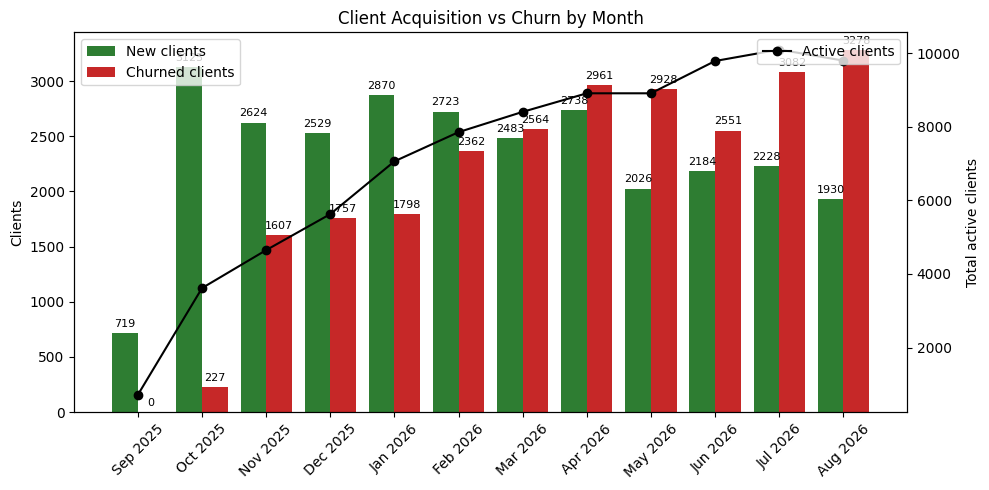

In [23]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(flow))
bars_new = ax1.bar([i - 0.2 for i in x], flow["New"], width=0.4, label="New clients", color="#2e7d32")
bars_churn = ax1.bar([i + 0.2 for i in x], flow["Churned"], width=0.4, label="Churned clients", color="#c62828")
ax1.set_xticks(list(x)); ax1.set_xticklabels(flow["Month"], rotation=45)
ax1.set_ylabel("Clients")
ax1.legend(loc="upper left")

# Add value labels on top of each bar
ax1.bar_label(bars_new, padding=3, fontsize=8)
ax1.bar_label(bars_churn, padding=3, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, flow["Active"], color="black", marker="o", label="Active clients")
ax2.set_ylabel("Total active clients")
ax2.legend(loc="upper right")

plt.title("Client Acquisition vs Churn by Month")
plt.tight_layout()
plt.show()

In [24]:
flow["Net Growth Rate %"] = (flow["Net Change"] / flow["Active"].shift(1) * 100).round(1)
flow["Cumulative Net Adds"] = flow["Net Change"].cumsum()
flow[["Month", "Active", "New", "Churned", "Net Change", "Net Growth Rate %"]]

,Month,Active,New,Churned,Net Change,Net Growth Rate %
0,Sep 2025,719,719,0,NaN,NaN
1,Oct 2025,3617,3125,227,2898.0,403.1
2,Nov 2025,4648,2624,1607,1031.0,28.5
3,Dec 2025,5626,2529,1757,978.0,21.0
4,Jan 2026,7059,2870,1798,1433.0,25.5
5,Feb 2026,7852,2723,2362,793.0,11.2
6,Mar 2026,8403,2483,2564,551.0,7.0
7,Apr 2026,8907,2738,2961,504.0,6.0
8,May 2026,8907,2026,2928,0.0,0.0
9,Jun 2026,9784,2184,2551,877.0,9.8


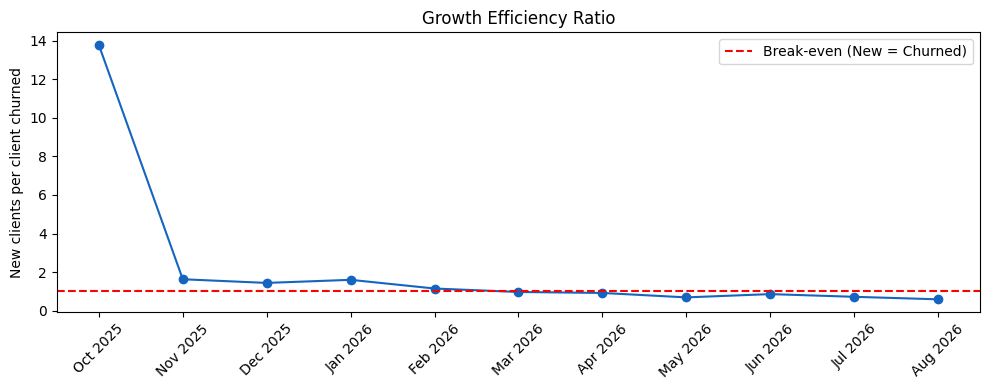

In [25]:
flow["Growth Efficiency"] = (flow["New"] / flow["Churned"]).round(2)

plt.figure(figsize=(10, 4))
plt.plot(flow["Month"], flow["Growth Efficiency"], marker="o", color="#1565c0")
plt.axhline(1.0, color="red", linestyle="--", label="Break-even (New = Churned)")
plt.xticks(rotation=45)
plt.ylabel("New clients per client churned")
plt.title("Growth Efficiency Ratio")
plt.legend()
plt.tight_layout()
plt.show()

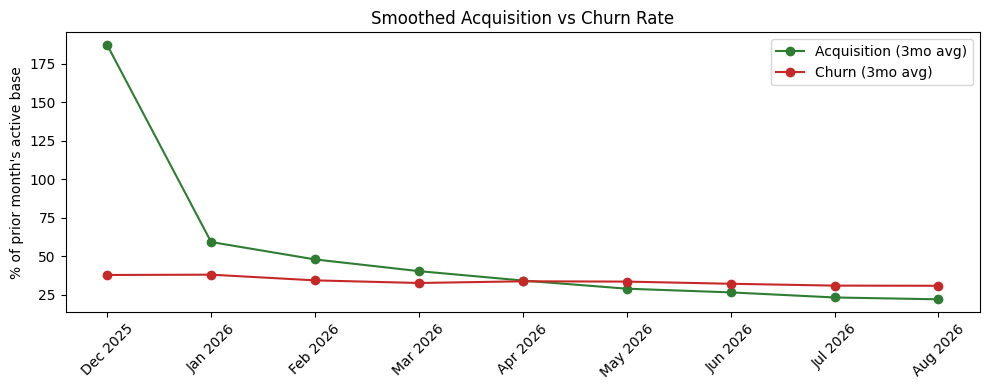

In [26]:
flow["Acquisition Rate (3mo avg)"] = flow["Acquisition Rate %"].rolling(3).mean().round(1)
flow["Churn Rate (3mo avg)"] = flow["Churn Rate %"].rolling(3).mean().round(1)

plt.figure(figsize=(10, 4))
plt.plot(flow["Month"], flow["Acquisition Rate (3mo avg)"], marker="o", label="Acquisition (3mo avg)", color="#2e7d32")
plt.plot(flow["Month"], flow["Churn Rate (3mo avg)"], marker="o", label="Churn (3mo avg)", color="#c62828")
plt.xticks(rotation=45)
plt.ylabel("% of prior month's active base")
plt.title("Smoothed Acquisition vs Churn Rate")
plt.legend()
plt.tight_layout()
plt.show()

count    3278.000000
mean        3.927700
std         3.097434
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        11.000000
Name: months_active, dtype: float64


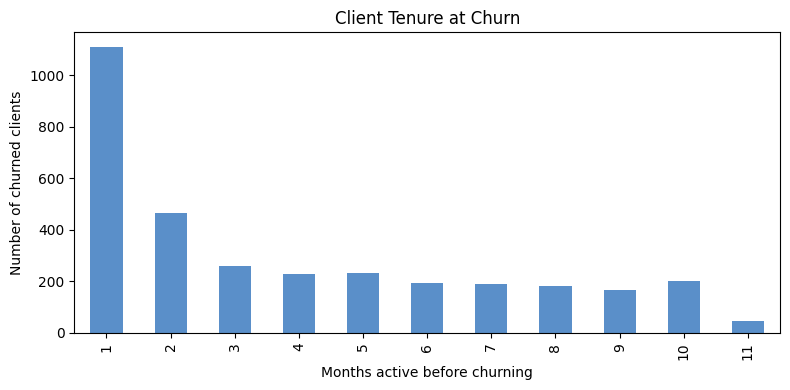

In [27]:
# Tenure (months active) for each client who has churned by the last full month
last_full_month = months[-2]  # exclude current partial month
churned_ever = active_sets[months[-2]] - active_sets[months[-1]]

tenure = (activity[activity["ClientID"].isin(churned_ever)]
          .groupby("ClientID")["Month"].agg(["min", "max"]))
tenure["months_active"] = ((tenure["max"] - tenure["min"]).apply(lambda x: x.n) + 1)

print(tenure["months_active"].describe())

plt.figure(figsize=(8, 4))
tenure["months_active"].value_counts().sort_index().plot(kind="bar", color="#5a8fc9")
plt.xlabel("Months active before churning")
plt.ylabel("Number of churned clients")
plt.title("Client Tenure at Churn")
plt.tight_layout()
plt.show()

In [28]:
avg_monthly_debit = (bills.groupby(["ClientID", "Month"])["Debit"].sum()
                      .groupby("ClientID").mean())  # avg revenue-per-active-month per client

flow_indexed = flow.set_index("Month")
revenue_lost = []
for i, m in enumerate(months[1:], start=1):
    churned_this_month = active_sets[months[i-1]] - active_sets[m]
    lost = avg_monthly_debit.reindex(churned_this_month).sum()
    revenue_lost.append(lost)

flow.loc[1:, "Est. Revenue Lost to Churn"] = revenue_lost
flow[["Month", "Churned", "Est. Revenue Lost to Churn"]]

,Month,Churned,Est. Revenue Lost to Churn
0,Sep 2025,0,NaN
1,Oct 2025,227,5.884876e+06
2,Nov 2025,1607,4.572448e+07
3,Dec 2025,1757,4.288969e+07
4,Jan 2026,1798,4.530289e+07
5,Feb 2026,2362,9.479695e+07
6,Mar 2026,2564,8.600293e+07
7,Apr 2026,2961,3.952777e+08
8,May 2026,2928,8.349408e+07
9,Jun 2026,2551,4.044533e+08
